# NHIỆM VỤ 7: ĐÁNH GIÁ CHẤT LƯỢNG CỤM (PCA + K-MEANS)

Notebook này thực hiện đánh giá độc lập từng chỉ số chất lượng phân cụm theo đúng kế hoạch (Mục 7.1 đến 7.5), sau đó tổng hợp lại.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display

if os.getcwd().endswith("notebooks"):
    os.chdir("../../")

output_dir = "M2/artifacts/m2-task6-pca-kmeans-v1"
diag_path = os.path.join(output_dir, "diagnostics.csv")

if os.path.exists(diag_path):
    diag_df = pd.read_csv(diag_path)
    diag_df = diag_df[diag_df['k'] == 2]  # Lọc đúng mức Global K=2
    print("Đã nạp thành công dữ liệu diagnostics.csv")
else:
    print("Lỗi: Chưa tìm thấy diagnostics.csv")

Đã nạp thành công dữ liệu diagnostics.csv


## 7.1 — Silhouette

In [2]:
silhouette_median = diag_df['silhouette'].median()
print(f"Trung vị Silhouette qua 15 tháng: {silhouette_median:.4f}")
display(diag_df[['snapshot_date', 'silhouette']].sort_values(by='silhouette', ascending=False))

Trung vị Silhouette qua 15 tháng: 0.7717


,snapshot_date,silhouette
84,2024-11-29,0.951234
77,2024-10-31,0.940062
70,2024-09-30,0.933450
91,2024-12-31,0.909545
63,2024-08-30,0.906888
98,2025-01-24,0.880644
0,2023-11-30,0.775353
7,2023-12-29,0.771666
49,2024-06-28,0.763995
21,2024-02-29,0.745119


## 7.2 — Davies–Bouldin (DB)

In [3]:
db_median = diag_df['davies_bouldin'].median()
print(f"Trung vị Davies–Bouldin qua 15 tháng: {db_median:.4f}")

Trung vị Davies–Bouldin qua 15 tháng: 0.5155


## 7.3 — Calinski–Harabasz (CH)

In [4]:
ch_median = diag_df['calinski_harabasz'].median()
print(f"Trung vị Calinski–Harabasz qua 15 tháng: {ch_median:.4f}")

Trung vị Calinski–Harabasz qua 15 tháng: 361.5279


## 7.4 — Inertia

Trung vị Inertia qua 15 tháng: 1963.07


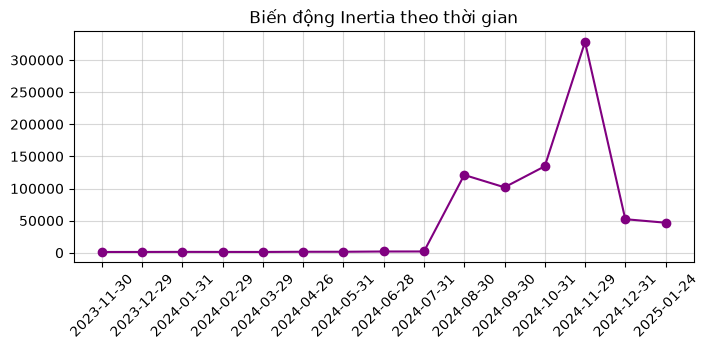

In [5]:
inertia_median = diag_df['inertia'].median()
print(f"Trung vị Inertia qua 15 tháng: {inertia_median:.2f}")

plt.figure(figsize=(8, 3))
plt.plot(diag_df['snapshot_date'], diag_df['inertia'], marker='o', color='purple')
plt.title("Biến động Inertia theo thời gian")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.show()

## 7.5 — Cluster balance

In [6]:
balance_median = diag_df['cluster_balance'].median()
print(f"Trung vị Cluster balance qua 15 tháng: {balance_median*100:.2f}%")

Trung vị Cluster balance qua 15 tháng: 6.77%


## BẢNG TỔNG HỢP (SUMMARY)

In [7]:
summary_df = pd.DataFrame({
    "Metric": ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "Inertia", "Cluster Balance (%)"],
    "Median Value": [round(silhouette_median, 4), round(db_median, 4), round(ch_median, 2), round(inertia_median, 2), round(balance_median * 100, 2)],
    "Đánh giá": ["Tuyệt hảo (> 0.7)", "Rất tốt (Thấp)", "Ổn định", "Biến động theo Size", "Mất cân bằng (Dị biệt)"]
})
print("TỔNG HỢP CHẤT LƯỢNG PHÂN CỤM (PCA + K-MEANS):")
display(summary_df.set_index("Metric"))

TỔNG HỢP CHẤT LƯỢNG PHÂN CỤM (PCA + K-MEANS):


,Median Value,Đánh giá
Metric,,
Silhouette,0.7717,Tuyệt hảo (> 0.7)
Davies-Bouldin,0.5155,Rất tốt (Thấp)
Calinski-Harabasz,361.5300,Ổn định
Inertia,1963.0700,Biến động theo Size
Cluster Balance (%),6.7700,Mất cân bằng (Dị biệt)
